In [11]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

In [12]:
load_dotenv()

True

In [13]:
db_user = os.getenv("POSTGRES_USER")
db_password = os.getenv("POSTGRES_PASSWORD")
db_name = os.getenv("POSTGRES_DB")
db_host = os.getenv("POSTGRES_HOST")
db_port = os.getenv("POSTGRES_PORT")

if not db_password:
    raise ValueError("CRITICAL: .env file was not found or POSTGRES_PASSWORD is completely empty!")

In [14]:
database_url = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"

In [15]:
engine = create_engine(database_url)

In [16]:
query = "SELECT * FROM sensor_readings ORDER BY timestamp ASC;"

In [17]:
df = pd.read_sql_query(query, con=engine)

In [18]:
print(f"Secure pipeline established! Loaded Matrix Shape: {df.shape}")
df.head()

Secure pipeline established! Loaded Matrix Shape: (3000, 5)


,id,line_id,sensor_type,value,timestamp
0,1,Line_1,torque,152.483571,2026-03-08 18:42:12.261548+00:00
1,2,Line_1,conveyor_speed,1198.657673,2026-03-08 18:42:12.261548+00:00
2,3,Line_1,fill_level,79.074585,2026-03-08 18:42:12.261548+00:00
3,4,Line_1,torque,235.705052,2026-03-08 18:43:12.261548+00:00
4,5,Line_1,conveyor_speed,744.177734,2026-03-08 18:43:12.261548+00:00


In [20]:
# 1. Reconstitute the long EAV database rows into a wide mathematical matrix
df_matrix = df.pivot(
    index=['timestamp', 'line_id'], 
    columns='sensor_type', 
    values='value'
).reset_index()

In [21]:
# Strip the categorical index name for a clean column layout
df_matrix.columns.name = None

In [22]:

print(f"Raw Database Records Extracted: {df.shape[0]} rows")
print(f"Reconstituted Snapshot Matrix:  {df_matrix.shape[0]} rows (1,000 chronological ticks)\n")

=== PRODUCTION MATRIX SHAPE DETECTED ===
• Raw Database Records Extracted: 3000 rows
• Reconstituted Snapshot Matrix:  1000 rows (1,000 chronological ticks)



In [34]:
# Compute comprehensive statistical distributions simultaneously
df_summary = df_matrix[['conveyor_speed', 'fill_level', 'torque']].describe()
# df_summary.head()
df_matrix.head()

,timestamp,line_id,conveyor_speed,fill_level,torque
0,2026-03-08 18:42:12.261548+00:00,Line_1,1198.657673,79.074585,152.483571
1,2026-03-08 18:43:12.261548+00:00,Line_1,744.177734,48.801993,235.705052
2,2026-03-08 18:44:12.261548+00:00,Line_1,1198.145634,79.383023,153.238443
3,2026-03-08 18:45:12.261548+00:00,Line_1,1197.860299,81.018888,157.615149
4,2026-03-08 18:46:12.261548+00:00,Line_1,1200.770371,78.916180,148.829233


In [23]:

df_summary.loc['iqr'] = df_summary.loc['75%'] - df_summary.loc['25%']

In [24]:
# Display our baseline operational envelopes
df_summary.loc[['mean', 'std', 'iqr']]

,conveyor_speed,fill_level,torque
mean,1176.746394,78.254627,154.599800
std,97.340400,7.155327,18.889204
iqr,13.710898,1.422793,6.952723


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

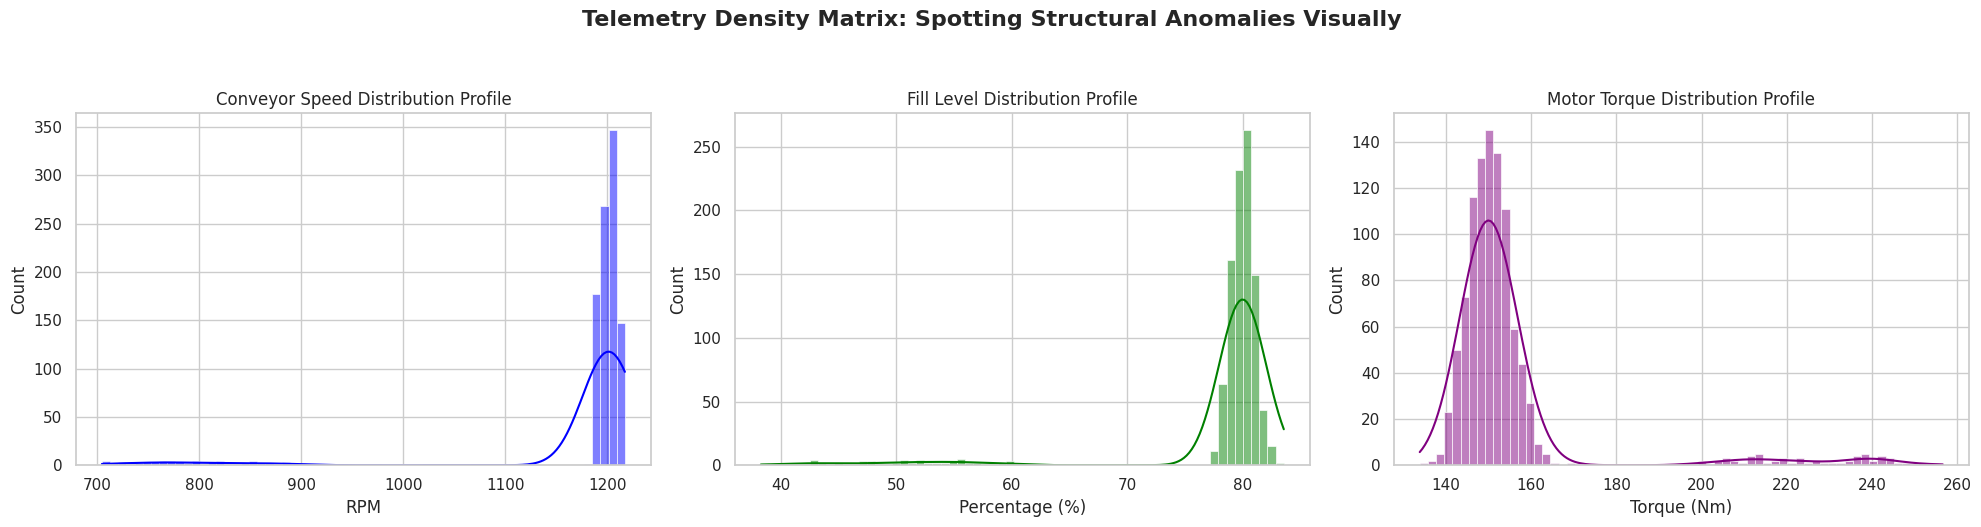

In [27]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot kernel density distributions for all three sensors
sns.histplot(data=df_matrix, x="conveyor_speed", kde=True, ax=axes[0], color="blue")
axes[0].set_title("Conveyor Speed Distribution Profile")
axes[0].set_xlabel("RPM")

sns.histplot(data=df_matrix, x="fill_level", kde=True, ax=axes[1], color="green")
axes[1].set_title("Fill Level Distribution Profile")
axes[1].set_xlabel("Percentage (%)")

sns.histplot(data=df_matrix, x="torque", kde=True, ax=axes[2], color="purple")
axes[2].set_title("Motor Torque Distribution Profile")
axes[2].set_xlabel("Torque (Nm)")

plt.suptitle("Telemetry Density Matrix: Spotting Structural Anomalies Visually", fontsize=16, weight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [28]:
print("=== COMPUTING CHRONOLOGICAL ROLLING FEATURES ===")
# Create a copy of our wide matrix and ensure it is sorted perfectly by time
df_features = df_matrix.sort_values(by="timestamp").copy()

# Compute 30-minute (30 rows) rolling statistics for each sensor stream
# We use min_periods=1 so that the code doesn't return empty values at the very start
df_features["speed_roll_mean"] = df_features["conveyor_speed"].rolling(window=30, min_periods=1).mean()
df_features["speed_roll_std"]  = df_features["conveyor_speed"].rolling(window=30, min_periods=1).std().fillna(0)

# Calculate the dynamic, time-aware Rolling Z-Score for conveyor speed
# We add a tiny epsilon (1e-6) to prevent a ZeroDivisionError if std ever hits exactly 0
df_features["speed_z_score"] = (df_features["conveyor_speed"] - df_features["speed_roll_mean"]) / (df_features["speed_roll_std"] + 1e-6)

print("Feature transformation complete! Dynamic Z-scores generated.")
df_features[["timestamp", "conveyor_speed", "speed_roll_mean", "speed_roll_std", "speed_z_score"]].head(10)

=== COMPUTING CHRONOLOGICAL ROLLING FEATURES ===
Feature transformation complete! Dynamic Z-scores generated.


,timestamp,conveyor_speed,speed_roll_mean,speed_roll_std,speed_z_score
0,2026-03-08 18:42:12.261548+00:00,1198.657673,1198.657673,0.000000,0.000000
1,2026-03-08 18:43:12.261548+00:00,744.177734,971.417703,321.365847,-0.707107
2,2026-03-08 18:44:12.261548+00:00,1198.145634,1046.993680,262.246427,0.576374
3,2026-03-08 18:45:12.261548+00:00,1197.860299,1084.710335,227.021974,0.498410
4,2026-03-08 18:46:12.261548+00:00,1200.770371,1107.922342,203.342614,0.456609
5,2026-03-08 18:47:12.261548+00:00,1199.654329,1123.211007,185.690696,0.411670
6,2026-03-08 18:48:12.261548+00:00,1201.309688,1134.367961,172.062602,0.389054
7,2026-03-08 18:49:12.261548+00:00,1200.246534,1142.602783,160.992778,0.358052
8,2026-03-08 18:50:12.261548+00:00,1199.226420,1148.894298,151.773149,0.331627
9,2026-03-08 18:51:12.261548+00:00,1202.510188,1154.255887,144.094069,0.334881


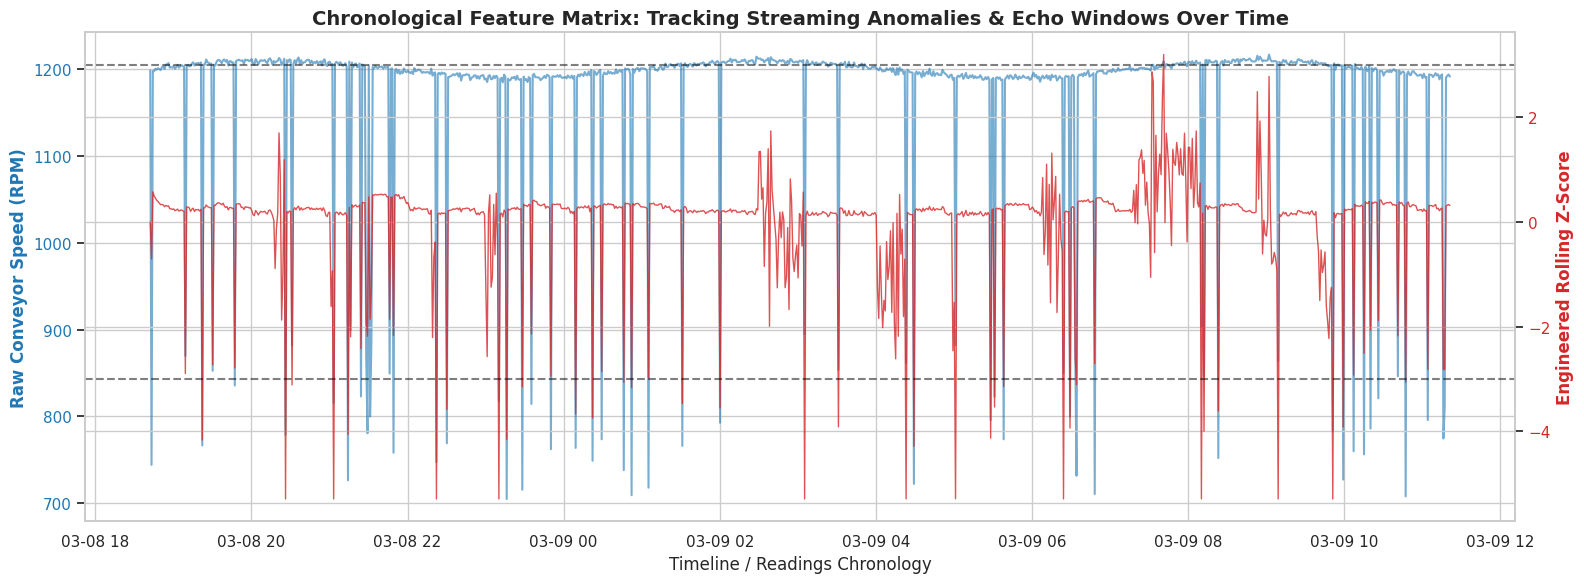

In [29]:
# Set up a dual-axis plotting layout
fig, ax1 = plt.subplots(figsize=(16, 6))

# 1. Plot the Raw Conveyor Speed timeline on the left axis
color = 'tab:blue'
ax1.set_xlabel('Timeline / Readings Chronology')
ax1.set_ylabel('Raw Conveyor Speed (RPM)', color=color, weight="bold")
ax1.plot(df_features['timestamp'], df_features['conveyor_speed'], color=color, alpha=0.6, label="Raw Speed")
ax1.tick_params(axis='y', labelcolor=color)

# 2. Instantiate a second axis sharing the exact same x-axis timeline
ax2 = ax1.twinx()  

# Plot our engineered Rolling Z-Score on the right axis
color = 'tab:red'
ax2.set_ylabel('Engineered Rolling Z-Score', color=color, weight="bold")
ax2.plot(df_features['timestamp'], df_features['speed_z_score'], color=color, alpha=0.8, linewidth=1, label="Z-Score")
ax2.tick_params(axis='y', labelcolor=color)

# Draw our industrial standard statistical anomaly thresholds (+/- 3 standard deviations)
ax2.axhline(y=3.0, color='black', linestyle='--', alpha=0.5, label="Threshold Boundary (+3σ)")
ax2.axhline(y=-3.0, color='black', linestyle='--', alpha=0.5)

plt.title("Chronological Feature Matrix: Tracking Streaming Anomalies & Echo Windows Over Time", fontsize=14, weight="bold")
fig.tight_layout()
plt.show()